# Project Title : Customer Review Sentiment Analysis System

# By : Niraj Khankari

## Importing Libraries

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

## Loading Dataset 

In [4]:
df1 = pd.read_csv("Airbnb Reviews_data_dictionary.csv")
df2 = pd.read_csv("Amazon Ratings.csv")
df3 = pd.read_csv("IMDB-Dataset.csv")
df4 = pd.read_csv("twitter_training.csv")
df5 = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

## Showing at least 5 reviews

In [7]:
df1.head()

,Field,Description
0,listing_id,Listing ID
1,review_id,Review ID
2,date,Review date
3,reviewer_id,Reviewer ID


In [9]:
df2.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [11]:
df3.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
df4.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [15]:
df5.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## Understanding Dataset 

In [18]:
df1.shape

(4, 2)

In [20]:
df2.shape

(1149780, 3)

In [22]:
df3.shape

(50000, 2)

In [24]:
df4.shape

(74681, 4)

In [26]:
df5.shape

(23486, 11)

In [29]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Field        4 non-null      object
 1   Description  4 non-null      object
dtypes: object(2)
memory usage: 196.0+ bytes


In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [33]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [35]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [37]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


## Checking Columns of All Datasets

In [40]:
print(df1.columns)

Index(['Field', 'Description'], dtype='object')


In [42]:
print(df1.columns.tolist())

['Field', 'Description']


In [44]:
print(df2.columns)

Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object')


In [46]:
print(df3.columns)

Index(['review', 'sentiment'], dtype='object')


In [48]:
print(df4.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [50]:
print(df5.columns)

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')


# Note : As Dataset 1 & 2 are not proper for Sentiment Analysis. Will go Forward with Dataset 3, 4, 5

## Checking of Missing Values

In [54]:
print(df3.isnull().sum())
print()
print(df4.isnull().sum())
print()
print(df5.isnull().sum())

review       0
sentiment    0
dtype: int64

2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


## Analysis of Dataset 3

In [57]:
print(df3.shape)
print(df3.head())
print(df3["sentiment"].value_counts())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [59]:
print(df3["sentiment"].value_counts())
print(df3["sentiment"].unique())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64
['positive' 'negative']


## Analysis of Dataset 4

In [63]:
print(df4.shape)
print(df4.head())

(74681, 4)
   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     


In [65]:
df4 = pd.read_csv("twitter_training.csv", header=None)

In [67]:
df4.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [69]:
df4.columns = ["id", "topic", "sentiment", "review"]

In [71]:
df4.head

<bound method NDFrame.head of          id        topic sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   
...     ...          ...       ...   
74677  9200       Nvidia  Positive   
74678  9200       Nvidia  Positive   
74679  9200       Nvidia  Positive   
74680  9200       Nvidia  Positive   
74681  9200       Nvidia  Positive   

                                                  review  
0      im getting on borderlands and i will murder yo...  
1      I am coming to the borders and I will kill you...  
2      im getting on borderlands and i will kill you ...  
3      im coming on borderlands and i will murder you...  
4      im getting on borderlands 2 and i will murder ...  
...                                                  ...  
74677  Just realized that the Windows partition of my...  
74678  Just realized that my Mac window p

In [73]:
df4["sentiment"].value_counts()

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [75]:
df4["sentiment"].unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

## Analysis of Dataset 5

In [84]:
print(df5.shape)
print(df5.head())
print(df5["Rating"].value_counts().sort_index())

(23486, 11)
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   Positive Feedback Count   Division Name Department Name Class Name  
0                        0       Initmates        Intimate  Intimate

In [110]:
print(df5["Recommended IND"].value_counts())

Recommended IND
1    19314
0     4172
Name: count, dtype: int64


## Preparing Dataset Proper Format 

In [80]:
df3_clean = df3[["review", "sentiment"]].copy()  # Creating a separate DataFrame

In [82]:
df3_clean["sentiment"] = df3_clean["sentiment"].str.strip().str.lower() # standardizing the sentiment labels

In [84]:
df3_clean.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [86]:
df3_clean["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [89]:
df4_clean = df4[["review", "sentiment"]].copy()

In [91]:
df4_clean["sentiment"] = df4_clean["sentiment"].str.strip().str.lower()

In [93]:
df4_clean["sentiment"].value_counts()

sentiment
negative      22542
positive      20832
neutral       18318
irrelevant    12990
Name: count, dtype: int64

In [115]:
df5_clean = df5.dropna(subset=["Review Text"]).copy()

def rating_to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

In [117]:
df5_clean["sentiment"] = df5_clean["Rating"].apply(rating_to_sentiment)

In [119]:
df5_clean = df5_clean.rename(columns={
    "Review Text": "review"
})

In [121]:
df5_clean = df5_clean[["review", "sentiment"]]

In [123]:
df5_clean["sentiment"].value_counts()

sentiment
positive    17448
neutral      2823
negative     2370
Name: count, dtype: int64

## Combining the Prepared Datasets

In [126]:
combined_df = pd.concat(
    [df3_clean, df4_clean, df5_clean],
    ignore_index=True
)

In [128]:
combined_df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [130]:
combined_df.shape

(147323, 2)

In [132]:
combined_df["sentiment"].value_counts()

sentiment
positive      63280
negative      49912
neutral       21141
irrelevant    12990
Name: count, dtype: int64

In [134]:
combined_df["sentiment"].value_counts(normalize=True) * 100

sentiment
positive      42.953239
negative      33.879299
neutral       14.350101
irrelevant     8.817360
Name: proportion, dtype: float64

## Removing Duplicate Reviews

In [138]:
combined_df = combined_df.drop_duplicates(subset=["review"])

In [140]:
print("Dataset size after removing duplicates:", combined_df.shape)

Dataset size after removing duplicates: (141708, 2)


## Cleaning the Dataset

### Creating a preprocessing function 

In [143]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    
    return text

In [146]:
combined_df["clean_review"] = combined_df["review"].apply(clean_text)

## Comparing the Original & Cleaned Dataset

In [149]:
print("Original:")
print(combined_df["review"].iloc[0])

print("\nCleaned:")
print(combined_df["clean_review"].iloc[0])

Original:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

In [216]:
X = combined_df["clean_review"]
y = combined_df["sentiment"]

In [218]:
print(X.shape)
print(y.shape)

(141610,)
(141610,)


## Now Removing Empty Reviews

In [152]:
combined_df = combined_df[
    combined_df["clean_review"].str.strip() != ""
]

In [156]:
combined_df = combined_df.reset_index(drop=True) #Resetting the Index

## Final Dataset Check-up

In [159]:
print("Total reviews:", len(combined_df))

Total reviews: 141610


In [161]:
print("\nSentiment distribution:")
print(combined_df["sentiment"].value_counts())


Sentiment distribution:
sentiment
positive      61373
negative      48209
neutral       19830
irrelevant    12198
Name: count, dtype: int64


In [163]:
print("\nMissing values:")
print(combined_df[["clean_review", "sentiment"]].isnull().sum())


Missing values:
clean_review    0
sentiment       0
dtype: int64


In [165]:
print("\nDuplicate reviews:")
print(combined_df["clean_review"].duplicated().sum())


Duplicate reviews:
3809


## Visualizing the class distribution

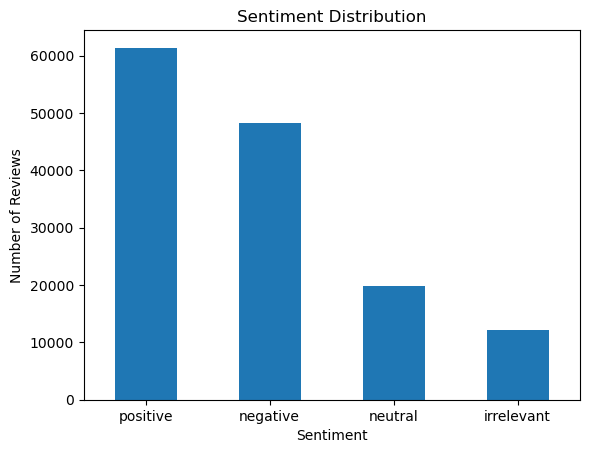

In [177]:
combined_df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## By Machine Learning for Training/Testing Data

In [220]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (113288,)
Testing Data: (28322,)


## TF-IDF

In [222]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(113288, 10000)
(28322, 10000)


## Logistic Regression

In [224]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

## Prediction

In [226]:
y_pred = model.predict(X_test_tfidf)

In [230]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
46556,positive,positive
97121,negative,negative
96620,irrelevant,irrelevant
140399,negative,neutral
7151,negative,negative
12772,positive,positive
126860,positive,positive
114381,negative,negative
40802,positive,positive
28763,negative,negative


## Accuracy 

In [232]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy*100)

Accuracy: 0.7648118070757715
Accuracy Percentage: 76.48118070757715


## Classification Reports

In [234]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  irrelevant       0.63      0.50      0.56      2440
    negative       0.79      0.81      0.80      9642
     neutral       0.67      0.54      0.60      3966
    positive       0.79      0.86      0.82     12274

    accuracy                           0.76     28322
   macro avg       0.72      0.68      0.69     28322
weighted avg       0.76      0.76      0.76     28322



## Confusion Matrix

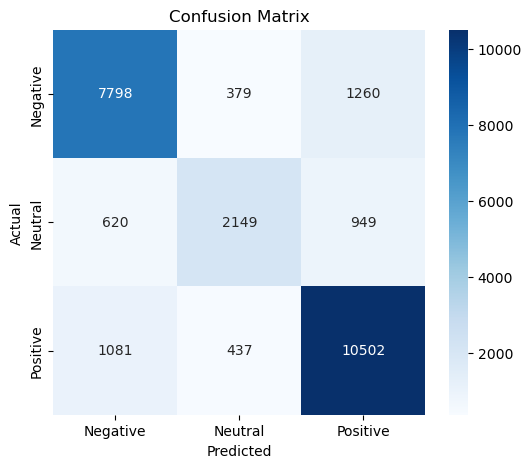

In [237]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Now Testing Own Reviews

In [239]:
new_reviews = [
    "The product quality is amazing and I am very happy.",
    "The service was terrible and disappointing.",
    "The package arrived today."
]

In [241]:
new_reviews_clean = [clean_text(review) for review in new_reviews] #Transforming

In [243]:
new_reviews_tfidf = vectorizer.transform(new_reviews_clean)

In [245]:
predictions = model.predict(new_reviews_tfidf) # predicting

In [250]:
for review, pred in zip(new_reviews, predictions):  # Displaying
    print("Review :", review)
    print("Prediction :", pred)
    print("-"*50)

Review : The product quality is amazing and I am very happy.
Prediction : positive
--------------------------------------------------
Review : The service was terrible and disappointing.
Prediction : negative
--------------------------------------------------
Review : The package arrived today.
Prediction : negative
--------------------------------------------------


## Conclusion